EDA- requires a low pass filter.

In [28]:
import pandas as pd

data = pd.read_csv("../../data/raw/WESAD/S2/S2_E4_Data/EDA.csv", header=None, names=["EDA"])
print(data.head())
print(data.columns)


eda_raw = data['EDA'].iloc[2:].astype(float).values 


            EDA
0  1.495437e+09
1  4.000000e+00
2  0.000000e+00
3  3.280210e-01
4  4.100260e-01
Index(['EDA'], dtype='str')


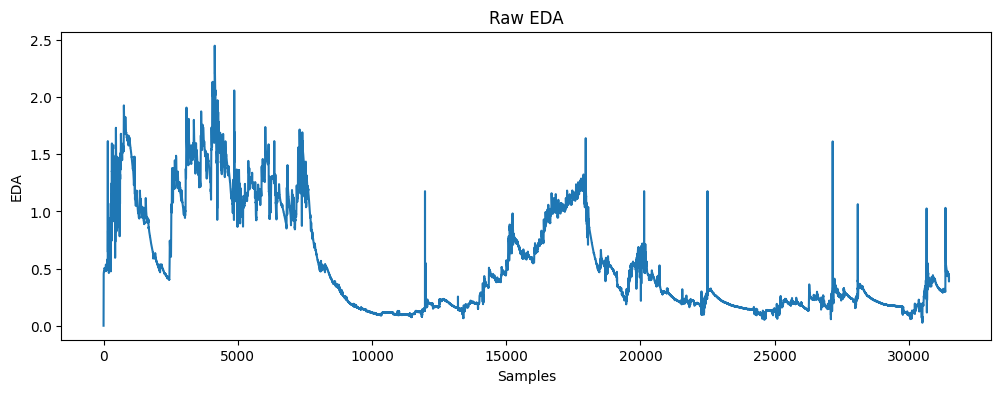

In [29]:
# VISUALIZATION
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(eda_raw)
plt.title("Raw EDA")
plt.xlabel("Samples")
plt.ylabel("EDA")
plt.show()

In [30]:
import scipy.signal
from scipy.signal import butter, filtfilt, medfilt


def lowpass_filter(signal, cutoff, fs, order=4):
    nyquist = fs / 2
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low')
    return filtfilt(b, a, signal)

In [31]:
eda_filtered = lowpass_filter(
    eda_raw,
    cutoff=1,
    fs=4
)

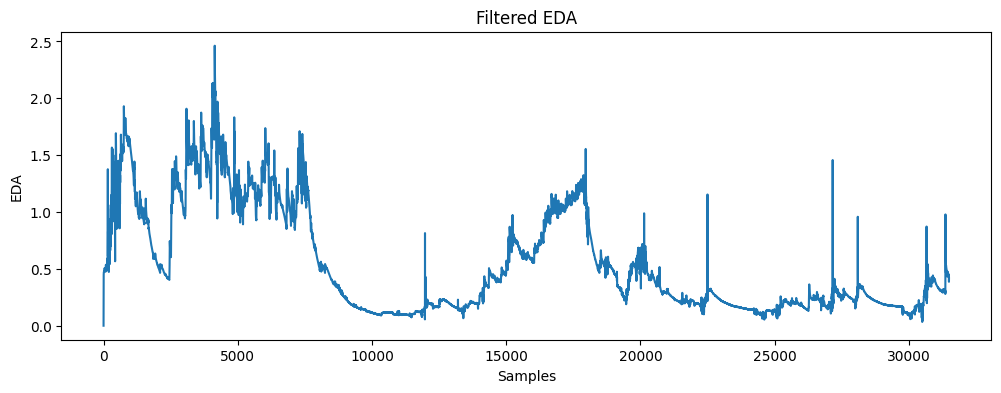

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(eda_filtered)
plt.title("Filtered EDA")
plt.xlabel("Samples")
plt.ylabel("EDA")
plt.show()

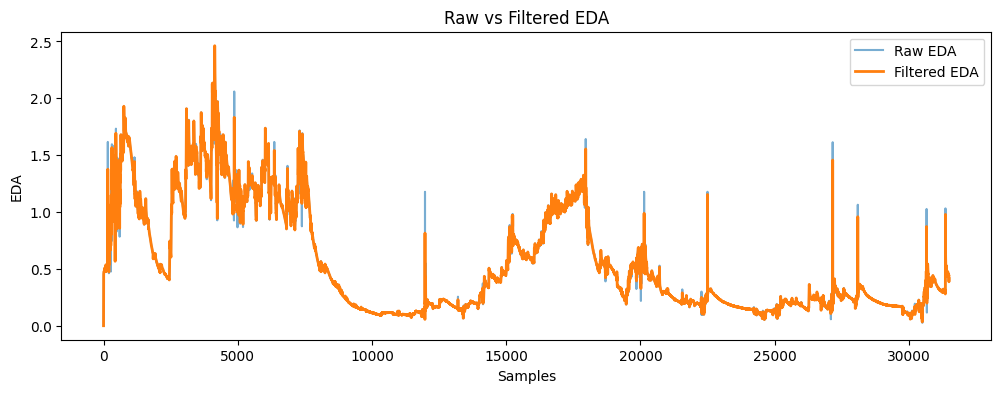

In [33]:
# Compare them on the same graph
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.plot(eda_raw, label='Raw EDA', alpha=0.6)
plt.plot(eda_filtered, label='Filtered EDA', linewidth=2)
plt.xlabel("Samples")
plt.ylabel("EDA")
plt.legend()
plt.title("Raw vs Filtered EDA")
plt.show()

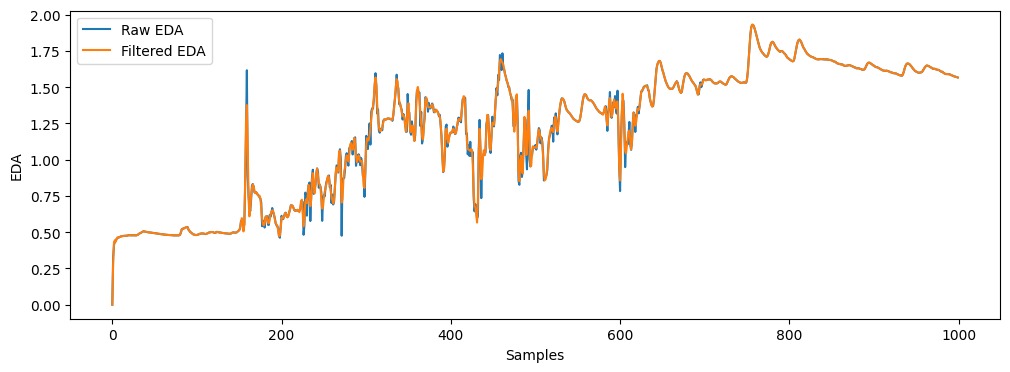

In [34]:
# Plot only a portion:
plt.figure(figsize=(12,4))

plt.plot(eda_raw[:1000], label='Raw EDA')
plt.plot(eda_filtered[:1000], label='Filtered EDA')
plt.xlabel("Samples")
plt.ylabel("EDA")
plt.legend()
plt.show()

In [35]:
import numpy as np
from scipy.signal import find_peaks
from scipy.stats import linregress

# -------------------------
# Noise
# -------------------------
def calculate_noise(signal):
    return np.std(np.diff(signal))

# -------------------------
# Spikes
# -------------------------
def count_spikes(signal, threshold=3):
    diff_signal = np.abs(np.diff(signal))
    spike_threshold = threshold * np.std(diff_signal)
    return np.sum(diff_signal > spike_threshold)

# -------------------------
# Peaks (EDA-specific)
# -------------------------
def count_peaks(signal, prominence=0.02):
    peaks, _ = find_peaks(signal, prominence=prominence)
    return len(peaks)

# -------------------------
# Drift
# -------------------------
def calculate_drift(signal):
    x = np.arange(len(signal))
    slope, _, _, _, _ = linregress(x, signal)
    return slope

# -------------------------
# Metrics Function
# -------------------------
def get_metrics(signal):
    return {
        "Samples": len(signal),
        "Mean": np.mean(signal),
        "Std": np.std(signal),
        "Noise": calculate_noise(signal),
        "Spikes": count_spikes(signal),
        "Peaks": count_peaks(signal),
        "Drift": calculate_drift(signal)
    }

# -------------------------
# Calculate Metrics
# -------------------------
raw_metrics = get_metrics(eda_raw)
filtered_metrics = get_metrics(eda_filtered)

# -------------------------
# Print Results
# -------------------------
print("========== RAW EDA ==========")
for key, value in raw_metrics.items():
    print(f"{key:<10}: {value}")

print("\n========== FILTERED EDA ==========")
for key, value in filtered_metrics.items():
    print(f"{key:<10}: {value}")

========== RAW EDA ==========
Samples   : 31494
Mean      : 0.5478223880104146
Std       : 0.46081414615229327
Noise     : 0.024727757661578493
Spikes    : 430
Peaks     : 753
Drift     : -3.201999789040934e-05

========== FILTERED EDA ==========
Samples   : 31494
Mean      : 0.5478219366606292
Std       : 0.4606991855891192
Noise     : 0.017869333467055756
Spikes    : 499
Peaks     : 576
Drift     : -3.201988431807015e-05


In [36]:
print("\n========== CHANGE ==========")

for key in ["Noise", "Spikes", "Peaks", "Drift"]:
    
    raw = raw_metrics[key]
    filt = filtered_metrics[key]

    if raw != 0:
        change = ((filt - raw) / raw) * 100
        print(f"{key:<10}: {change:.2f}%")


========== CHANGE ==========
Noise     : -27.74%
Spikes    : 16.05%
Peaks     : -23.51%
Drift     : -0.00%


Short Conclusion
Noise Level: Reduced from 0.0247 to 0.0179 (~28% reduction), indicating successful noise removal.
Peak Count: Reduced from 753 to 576 (~24% reduction), suggesting smoothing of small fluctuations and minor peaks.
Drift Slope: Remained almost unchanged (-3.202×10⁻⁵), meaning the filter preserved the overall signal trend.
Mean and Standard Deviation: Changed very little, showing that the filter maintained the signal's overall characteristics.
Spike Count: Increased from 430 to 499, which may indicate that the current spike detection method is sensitive to the filtered signal and should be interpreted cautiously.

Overall: The low-pass filter effectively reduced high-frequency noise while preserving the signal's amplitude distribution and long-term trend. The decrease in peak count indicates smoothing, but the increase in detected spikes suggests that the spike detection metric may need adjustment for filtered EDA signals.